# Assignment 4: Cars

In this assignment, we use a simple linear regression model to try to predict the prices of used cars. The dataset `blocket_cars.csv` is available on Canvas. The data has been scraped from [Blocket](https://www.blocket.se/) which is the largest website for selling used cars in Sweden (among a myriad of other things). We will also use a simple logistic regression model to try to predict whether a car has automatic or manual transmission.

## Research consent
We would like to use your answers for research purposes. We are conducting a master thesis where automatic grading of plots is investigated. During this course, the plots will be graded manually. However, we would like to use as many submissions as possible for evaluating the AI-based automatic grader that is being developed as part of the master thesis.

Your submissions will be exported in bulk from CodeGrade and the **Python code** is extracted from the notebooks. All textual answers are removed and the code snippets are anonymized in such a way that it will not be possible to link them back to individual students. The data will not be made public and will only be accessed by the master thesis workers and their supervisor (the examiner of this course).

Please set the variable `RESEARCH_CONSENT` to be either `True` or `False`, depending if you agree to participate in the research or not, respectively. That is, if you set the variable `True`, your data will be used for research. If you set the variable `False`, your submission will be removed from the dataset.

The autograder will not give you a grade unless you set the variable either `True` or `False`.

In [ ]:
# Codegrade Tag ResearchConsent
# Do *not* remove the tag above
# Redefine the variable below to False if you do not want to participate in research
RESEARCH_CONSENT = True

## Question 1

Before we get started with the actual data, implement the simple linear regression model below. You may assume the data has only 1 feature (1-dimensional data). The interface should match that of [`sklearn.linear_model.LinearRegression`](https://scikit-learn.org/1.6/modules/generated/sklearn.linear_model.LinearRegression.html), however, you are not allowed to use sklearn in this question; you need to implement the class yourself.

The class should fit a simple univariate linear model of the form `y = \hat\alpha + \beta x` using least squares. That is, this is the classical least squares fit of a line in bivariate data.

The function `fit` should fit the model to the dataset. It should define the following member variables:
- `coef_` that contains the (single) coefficient of the model (the slope) as an `ndarray` of shape 1 (so it should be an array with one element, not just a plain number)
- `intercept_` that contains the intercept of the model as a plain floating-point number (so *not* as an array)
You can find the relevant formulae, for example, [in Wikipedia](https://en.wikipedia.org/wiki/Simple_linear_regression#Formulation_and_computation).

The function `predict` should take in an `n \times 1` array of observations and compute the predictions using the slope and intercept thus fitted.

It would be relatively straightforward to extend this model to handle multivariate cases, but this simple special case will be sufficient for our needs for now.

In [1]:
# Codegrade Tag Question1
# Do *not* remove the tag above
# Implement the class below

import numpy as np

class SimpleLinearRegression:
    """
    Uses closed-form formulae to implement the simple linear regression using least squares.
    """
    coef_ = np.zeros(1)
    intercept_ = 0
    
    def fit(self,X,y):
        """
        Fits the model on the observations (X,y) using least squares.

        Parameters:
        - X : n*1 array of univariate observations (independent variable)
        - y : n array of univariate observations (dependent variable)

        Return value:
        - Returns self
        """
        assert isinstance(X,np.ndarray) and isinstance(y,np.ndarray)        
        assert X.ndim == 2 and y.ndim == 1
        assert X.shape[0] == y.shape[0] and X.shape[1] == 1

        x_mean_diff = X - np.mean(X)
        y_mean_diff = y - np.mean(y)

        self.coef_[0] = np.sum(x_mean_diff.reshape(len(x_mean_diff)) * y_mean_diff) / np.sum(np.square(x_mean_diff))
        self.intercept_ = np.mean(y) - self.coef_[0] * np.mean(X)

        return self
        

    def predict(self,X):
        """
        Returns model predictions y = a+b*x for all observations given as input.

        Parameters:
        - X : n*1 array of univariate observations

        Return value:
        - An array of length n of predictions
        """
        assert isinstance(X,np.ndarray)
        assert X.ndim == 2 and X.shape[1] == 1

        return (X * self.coef_[0] + self.intercept_).reshape(len(X),) 


## Question 2: Preprocessing the dataset

Read the dataset into a dataframe called `df_raw`. Explore the data and try to understand what it says. Some points to be aware of:
- Price is given in SEK
- Mileage is given in [Scandinavian miles](https://en.wikipedia.org/wiki/Scandinavian_mile#Metric_mile), or *mil*
- [Horsepowers](https://en.wikipedia.org/wiki/Horsepower) refers to the power of the engine
- *Car type* refers to the chassis of the car (what kind of shape it is, which determines the purposes it is fit for)
- Engine size is given in cubic centimeters (cc)
- Registration date is the first registration date for traffic (when given)

Some of the observations are very suspicious or lacking. This may be because they are erroneous. We have a sufficient amount of data, so let's just remove all suspicious observations. Explore the data and remove rows that look suspicious. Be on the look out for incorrect units, or nonsensical values in some fields. Also, some prices are very suspicious, possibly because the cars are not actually for sale, but the price is for a leasing agreement that has been erroneously labelled as a sales price. Beware also of cars that have suspiciously high prices. Also, leave out completely new cars (with 0 mileage) as we want to focus solely on used cars. Also, leave out rows that are missing either price or transmission information as those are the target variables for our models.

Store the cleaned dataset as `df`.

The grader will complain if it spots certain obviously erroneous values in `df`. However, don't be too aggressive when pruning the data, you are expected to have at least 17,000 rows left.

Use `sklearn.model_selection.train_test_split` to perform a train-test split, such that you use 75% of the data for the training set. Use your favorite integer as the random seed. Save the training and test sets in `df_train` and `df_test`, respectively.

In [2]:
# Codegrade Tag Question2
# Do *not* remove the tag above
# Write your code below

import pandas as pd
from sklearn.model_selection import train_test_split

df_raw = pd.read_csv("blocket_cars.csv")
df = df_raw.copy()

df = df[df["Mileage"] > 0]

df = df[df["Price"].notna()]
df = df[df["Transmission"].notna()]

df = df[df["Price"] > df["Price"].quantile(0.01)]
df = df[df["Price"] < df["Price"].quantile(0.99)]

#df = df[df["Car type"].notna()]
df = df[df["Mileage"] < df["Mileage"].quantile(0.99)]
df = df[df["Horsepowers"] < df["Horsepowers"].quantile(0.999)]

df_train, df_test = train_test_split(df, test_size=0.25, random_state=51)

## Question 3

Compute the pearson correlation between all **numerical** features of the training dataset. Select the feature that has the highest correlation **in absolute value** with price and store the *name* of this feature in `most_correlated_feature`. Store the correlation coefficient in `most_correlated_feature_corr`.

In [3]:
# Codegrade Tag Question3
# Do *not* remove the tag above
# Write your code below

import pandas as pd

numeric_df = df_train.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

price_corr = correlation_matrix['Price'].drop('Price')

most_correlated_feature = price_corr.abs().idxmax()
most_correlated_feature_corr = price_corr[most_correlated_feature]

## Question 4

Train a simple univariate linear regression model using the most correlated feature identified in the previous question to predict the price of cars.

Compute $R^2$ with respect to the training set and store the value as `r2`. Then, compute Root Mean Square (RMS), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE) with respect to the test set. Store these metrics as `rms`, `mae`, and `mape`, respectively.

In [4]:
# Codegrade Tag Question4
# Do *not* remove the tag above
# Write your code below

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
 
X_train = df_train[[most_correlated_feature]]
y_train = df_train['Price']
X_test = df_test[[most_correlated_feature]]
y_test = df_test['Price']

model = LinearRegression()
model.fit(X_train, y_train)
r2 = model.score(X_train, y_train)
y_pred = model.predict(X_test)
rms = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

## Question 5

Plot the data in the test set as a scatter plot. On top of the scatter plot, plot the fitted line as a dotted red line. Use `subplots` to create an axis and make your plot in an axis object called `ax`. Label the axes and give the plot a title.

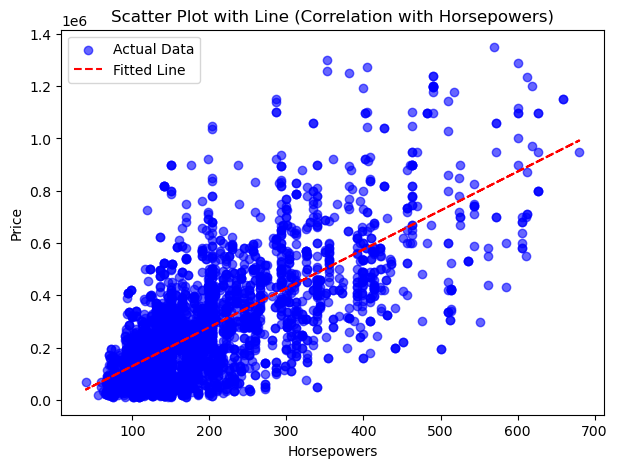

In [5]:
# Codegrade Tag Question5
# Do *not* remove the tag above
# Write your code below

import matplotlib.pyplot as plt
import numpy as np
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test, y_test, color='blue', label='Actual Data', alpha=0.6)
ax.plot(X_test, y_pred, color='red', linestyle='--', label='Fitted Line')
ax.set_xlabel(most_correlated_feature)
ax.set_ylabel('Price')
ax.set_title(f"Scatter Plot with Line (Correlation with {most_correlated_feature})")
ax.legend()
plt.show()

## Question 6

The previous model has limited value, which should be obvious by looking at the figure above. **Hypothesis:** This can be due to comparing apples and oranges. Surely, the markets of different kinds of cars behave differently? Premium brands vs. cheap brands, also the development of price may be different over long periods of time.

To address this, let us concentrate on a subset of the dataset. Determine the most common manufacturer of cars in the dataset. Store the name of the manufacturer in `top_manufacturer`. Then, select cars with model year **from and including** 2010, manufactured by the said manufacturer. Store the subsets in `df_train_top` and `df_test_top`. The idea here is that we may assume that prices of older cars behave differently, so we'll only model the prices of somewhat recent cars.

Determine the feature that has the highest correlation in absolute value with price and store the name of the feature in `most_correlated_feature_top` and the correlation in `most_correlated_feature_top_corr`.

Then, fit again a simple univariate linear regression model on the training set `df_train_top` with respect to the feature we just identified. Compute $R^2$ with respect to the training set in `r2_top` and the RMS, MAE, and MAPE with respect to the test set `df_test_top` in `rms_top`, `mae_top`, `mape_top`, respectively.

In [6]:
# Codegrade Tag Question6
# Do *not* remove the tag above
# Write your code below

top_manufacturer = df_train["Manufacturer"].value_counts().idxmax()
df_train_top = df_train[(df_train["Manufacturer"] == top_manufacturer) & (df_train["Model year"] >= 2010)]
df_test_top = df_test[(df_test["Manufacturer"] == top_manufacturer) & (df_test["Model year"] >= 2010)]

numeric_df_top = df_train_top.select_dtypes(include='number')
correlation_matrix_top = numeric_df_top.corr()

price_corr_top = correlation_matrix_top['Price'].drop('Price')

most_correlated_feature_top = price_corr_top.abs().idxmax()
most_correlated_feature_top_corr = price_corr_top[most_correlated_feature_top]

X_train_top = df_train_top[[most_correlated_feature_top]]
y_train_top = df_train_top['Price']
X_test_top = df_test_top[[most_correlated_feature_top]]
y_test_top = df_test_top['Price']

model_top = LinearRegression()
model_top.fit(X_train_top, y_train_top)
r2_top = model_top.score(X_train_top, y_train_top)
y_pred_top = model_top.predict(X_test_top)
rms_top = root_mean_squared_error(y_test_top, y_pred_top)
mae_top = mean_absolute_error(y_test_top, y_pred_top)
mape_top = mean_absolute_percentage_error(y_test_top, y_pred_top)

## Question 7

Like in Question 5, plot the fitted line as a dotted red line over the scatter plot of the test set `df_test_top`. Store the axis in `ax`, and label the axes and give the figure a descriptive title.

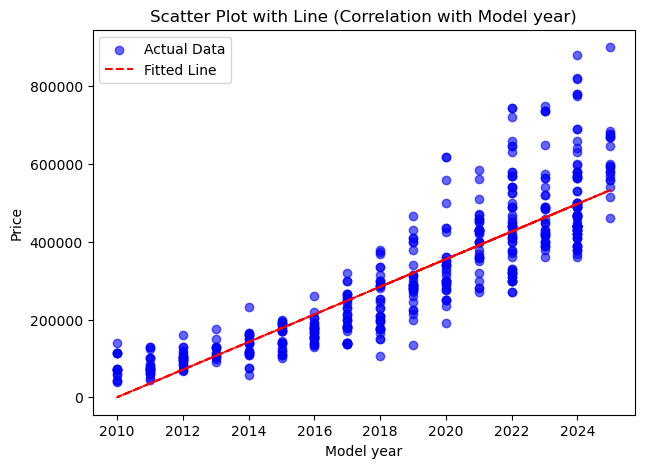

In [7]:
# Codegrade Tag Question7
# Do *not* remove the tag above
# Write your code below

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test_top, y_test_top, color='blue', label='Actual Data', alpha=0.6)
ax.plot(X_test_top, y_pred_top, color='red', linestyle='--', label='Fitted Line')
ax.set_xlabel(most_correlated_feature_top)
ax.set_ylabel('Price')
ax.set_title(f"Scatter Plot with Line (Correlation with {most_correlated_feature_top})")
ax.legend()
plt.show()

## Question 8

Although limiting ourselves to just one brand drastically improved the results, we can do even better if we include more variables in the model.

Construct a new, multivariate linear regression model that uses **up to three features** of the data. Store the names of the features you included in your model as a list called `mv_features`. Use the same `df_train_top` and `df_test_top` as in Question 6. Compute the $R^2$, RMS, MAE, and MAPE as before and store the values in `r2_mv`, `rms_mv`, `mae_mv`, `mape_mv`, respectively.

Your model should be able to reach $R^2>0.8$ and MAPE < 20%

In [8]:
# Codegrade Tag Question8
# Do *not* remove the tag above
# Write your code below

mv_features = ["Model year", "Mileage", "Horsepowers"]

X_train_mv = df_train_top[mv_features]
y_train_mv = df_train_top['Price']
X_test_mv = df_test_top[mv_features]
y_test_mv = df_test_top['Price']

model_mv = LinearRegression()
model_mv.fit(X_train_mv, y_train_mv)
r2_mv = model_mv.score(X_train_mv, y_train_mv)
y_pred_mv = model_mv.predict(X_test_mv)
rms_mv = root_mean_squared_error(y_test_mv, y_pred_mv)
mae_mv = mean_absolute_error(y_test_mv, y_pred_mv)
mape_mv = mean_absolute_percentage_error(y_test_mv, y_pred_mv)

## Question 9

Based on your metrics and findings above, how useful would you think the model is? Why? How could it be improved?

Another nice thing about linear regression is that it is *easy to reason* about it, it is an *explainable* model. Have a look at the coefficients of the model. How do the different things affect the decisions the model makes. How does this relate to what you know about the used cars market. (Beware: we have not normalized the scales of the features, so take this into account).

Write shortly, maybe 2–4 paragraphs.

The usefulness of the model depends on the performance measure calculated. R2 shows the proportion of the variance in the target variable/Price that the model explains. Whereas RMSE, MAS and MAPE shows us the magnitude of the the total errors. When R2 value is low, the linear regression model is not picking up the important patterns in the data. A high MAPE or RMSE would mean that forecasts were far apart from the real prices that is the model would not be suitable for the real-world pricing. Model1 is the model that has all the data after initial data cleaning and is trained with the feature that has the highest correlation with price (horsepowers), Model2 is the model that has only the most common brand and cars produced since 2010 and is trained with horsepowers. Model3 has the same dataset as Model2 but uses 3 features (model year, mileage, horsepowers).

The R2 score of Model3 is 89 percent and good. The R2 value of Model2 is average at around 75 percent and the R2 of Model1 is 48 percent, which is bad compared to the others. Since Model3 has more features, it gets better results. Including only vehicles produced since 2010 by the most common brand in Model2 and Model3's data resulted in less variation compared to Model1's data. Therefore, the Model2 and Model3 scored higher compared to the Model1.

When we look at the coefficients, in Model3, as the model year increases, the car price increases by about 17500 SEK. Each additional mileage decreases the price by 5.5 SEK. Each additional horsepower increases the price by 782 SEK. In Model1, the price increases by around 1488 SEK according to additional horsepower, while in Model2, it increases by around 35500 SEK. There is a correlation between newer and more powerful cars and prices, as expected in real life. Similarly, there is an inverse correlation between mileage and price, in real life we expect car prices to decrease as the mileage increases.

Model accuracy can be increased by adding more features, as seen in Model3. Normalizing the features can also contribute to accuracy. Since there are many features in the dataset that are not directly related to each other, using a non-linear model in this problem can also increase accuracy.

## Question 10: Logistic regression

Finally, we will try to predict whether the car has automatic or manual transmission based on the following features: price, horsepowers, model year, and mileage.

Encode the transmission information into a numerical binary feature such that we treat automatic transmission as the positive class (label 1) and manual transmission as the negative class (label 0).

Construct a logistic regression model using the full training data `df_train`, with the aforementioned features. Store your model in a variable called `lor`. Then, evaluate the accuracy, precision, recall, and $F$-score of your classifier with respect to `df_test`, and store the metrics in variables called `acc`, `prec`, `rec`, and `fscore`, respectively.

In [9]:
# Codegrade Tag Question10
# Do *not* remove the tag above
# Write your code below

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_features = ["Price", "Horsepowers", "Model year", "Mileage"]
X_train_log = df_train[log_features]
y_train_log = df_train['Transmission'].map({'Automatic': 1, 'Manual': 0}).astype(int)
X_test_log = df_test[log_features]
y_test_log = df_test['Transmission'].map({'Automatic': 1, 'Manual': 0}).astype(int)

lor = LogisticRegression().fit(X_train_log, y_train_log)
y_pred_log = lor.predict(X_test_log)

acc = accuracy_score(y_test_log, y_pred_log)
prec = precision_score(y_test_log, y_pred_log)
rec = recall_score(y_test_log, y_pred_log)
fscore = f1_score(y_test_log, y_pred_log)

## Question 11

How well did logistic regression perform in your opinion? Why is that?

Again, logistic regression is an explainable model. Have a look at the coefficients of the model. What features does the model weigh? Why does this seem to work? Relate this to what you know about the used cars market, and write shortly, maybe 2–4 paragraphs.

The performance of logistic regression depends on the accuracy, precision, recall and the F1 score. The logistic regression model performed quite well, achieving 84.1% accuracy, 88% precision, 89.4% recall, and an F1-score of 88.7%. According to these results, precision/recall are reasonably balanced. Thus the model is identified to be doing good indication of distinguishing between automatic and manual transmissions. The high recall shows that the model is good at classifying automatic cars correctly, while the strong precision shows it doesn’t misclassify too many manual cars as automatic.

When we look at the coefficients of our logistic regression model,  we see that horsepower has the highest positive coefficient as 0.0183, it means that cars with higher horsepowers are more likely to be automatic. These results align with current car market expectations. Automatic transmissions are more common in high-end, powerful cars, which explains the strong positive weight for horsepower and price. 
According to our results model year has a small negative coefficient (-2.143e-03) and it may be due to the dataset including a mix of manual sports cars and older luxury automatics. Mileage has a positive coefficient (1.192e-05) opposite to the expectations but it is very small and we can neglect it since it's not as powerful as other coefficients such as horsepower.

This logistic regression model seems to work because transmission type is evaluated based on factors like power and price. More powerful and more expensive cars tend to be automatic and less powerful, cheaper ones are more likely to be manual. Nevertheless, the model can be improved by adding more features such as car type, fuel or manufacturer. Because all these factors also influence transmission preferences.